# Notebook 03: Expected Shortfall (ES / CVaR)

This notebook implements Expected Shortfall, a tail risk measure that addresses VaR's limitations:

1. **Why ES over VaR?** - Regulatory and theoretical motivations
2. **Parametric ES** - Analytical formula under normality
3. **Historical ES** - Empirical tail average
4. **Monte Carlo ES** - Simulation-based approach
5. **VaR vs ES Comparison** - Understanding the difference

---

## 3.1 Why Expected Shortfall?

### VaR Limitations

Value-at-Risk has several shortcomings:

1. **VaR is not subadditive**: VaR of a portfolio can exceed the sum of individual VaRs (violates diversification principle)
2. **VaR ignores tail severity**: VaR tells you the threshold, not how bad losses can get beyond it
3. **VaR is not a coherent risk measure** (fails to satisfy all axioms of coherent risk measures)

### Expected Shortfall (ES)

ES, also known as Conditional VaR (CVaR) or Average Value-at-Risk (AVaR), answers:

> "If we exceed the VaR threshold, what is the expected loss?"

$$ES_{\alpha} = E[Loss \mid Loss > VaR_{\alpha}]$$

### Regulatory Requirement (FRTB / Basel IV)

The Fundamental Review of the Trading Book (FRTB) replaced VaR with ES as the primary risk metric:

- **ES at 97.5% confidence** (instead of VaR at 99%)
- Better captures tail risk
- Provides incentive for diversification

---

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import json
import warnings
warnings.filterwarnings('ignore')

# Statistical
from scipy.stats import norm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display
from IPython.display import display, Markdown
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load configuration and data
with open('../portfolio_config.json', 'r') as f:
    config = json.load(f)

CONFIDENCE_VAR = config['var_params']['confidence_var']    # 0.99
CONFIDENCE_ES = config['var_params']['confidence_es']      # 0.975 (FRTB requirement)
SIMULATIONS = config['var_params']['simulations']

TRAIN_START = config['dates']['train_start']
TRAIN_END = config['dates']['train_end']

# Load returns
portfolio_returns = pd.read_csv('../outputs/portfolio_returns.csv', index_col=0, parse_dates=True)['portfolio_return']
train_returns = portfolio_returns[TRAIN_START:TRAIN_END]

# Load VaR results from previous notebook
with open('../outputs/var_results.json', 'r') as f:
    var_results = json.load(f)

print(f"ES Confidence Level (FRTB): {CONFIDENCE_ES*100:.1f}%")
print(f"VaR Confidence Level: {CONFIDENCE_VAR*100:.0f}%")
print(f"Training observations: {len(train_returns)}")

ES Confidence Level (FRTB): 97.5%
VaR Confidence Level: 99%
Training observations: 731


## 3.2 Parametric Expected Shortfall

Under the normal distribution assumption, ES has a closed-form solution:

$$ES_{\alpha} = \mu - \sigma \times \frac{\phi(z_{\alpha})}{1 - \alpha}$$

Where:
- $\mu$ = mean return
- $\sigma$ = standard deviation
- $\phi$ = standard normal PDF
- $z_{\alpha}$ = z-score at confidence level $\alpha$
- $(1 - \alpha)$ = tail probability

In [ ]:
def parametric_es(returns, confidence=0.975):
    """
    Calculate Parametric Expected Shortfall (ES/CVaR).
    
    Under normality assumption, ES has a closed-form solution:
    ES = μ - σ × φ(z_α) / (1 - α)
    
    Where φ is the standard normal PDF.
    
    Parameters:
    -----------
    returns : pd.Series
        Historical returns
    confidence : float
        Confidence level (e.g., 0.975 for 97.5% FRTB requirement)
        
    Returns:
    --------
    float
        ES as a negative number (expected loss in tail)
    """
    # Step 1: Calculate distribution parameters
    mu = returns.mean()      # Mean return
    sigma = returns.std()    # Standard deviation
    
    # Step 2: Get z-score at confidence level
    # For 97.5% confidence: z = norm.ppf(0.025) = -1.96
    z_alpha = norm.ppf(1 - confidence)
    
    # Step 3: Calculate PDF value at z_alpha
    # φ(z) = (1/√2π) × e^(-z²/2)
    # This is the height of the normal curve at the VaR threshold
    phi_z = norm.pdf(z_alpha)
    
    # Step 4: Apply ES formula
    # ES = μ - σ × φ(z) / (1 - α)
    # The term φ(z)/(1-α) is the expected value of a standard normal
    # truncated below z_alpha, giving us the average loss in the tail
    tail_probability = 1 - confidence  # e.g., 0.025 for 97.5%
    es = mu - sigma * phi_z / tail_probability
    
    return es

def parametric_var(returns, confidence=0.99):
    """Calculate Parametric VaR for comparison."""
    mu = returns.mean()
    sigma = returns.std()
    z_score = norm.ppf(1 - confidence)
    return mu + z_score * sigma

In [4]:
# Calculate Parametric ES at both confidence levels
param_es_975 = parametric_es(train_returns, 0.975)   # FRTB
param_es_99 = parametric_es(train_returns, 0.99)    # For comparison with VaR

param_var_975 = parametric_var(train_returns, 0.975)
param_var_99 = parametric_var(train_returns, 0.99)

print("Parametric Risk Measures")
print("="*50)
print(f"\n97.5% Confidence (FRTB Standard):")
print(f"  VaR: {param_var_975:.4%} (potential loss: {abs(param_var_975):.4%})")
print(f"  ES:  {param_es_975:.4%} (expected tail loss: {abs(param_es_975):.4%})")
print(f"\n99% Confidence:")
print(f"  VaR: {param_var_99:.4%} (potential loss: {abs(param_var_99):.4%})")
print(f"  ES:  {param_es_99:.4%} (expected tail loss: {abs(param_es_99):.4%})")

Parametric Risk Measures

97.5% Confidence (FRTB Standard):
  VaR: -3.7071% (potential loss: 3.7071%)
  ES:  -4.4341% (expected tail loss: 4.4341%)

99% Confidence:
  VaR: -4.4121% (potential loss: 4.4121%)
  ES:  -5.0641% (expected tail loss: 5.0641%)


## 3.3 Historical Expected Shortfall

Historical ES is the average of all returns that fall below (worse than) the VaR threshold:

$$ES = \frac{1}{n_{tail}} \sum_{r_i < VaR} r_i$$

This approach:
- Makes no distributional assumptions
- Naturally captures fat tails
- Is limited by historical sample size

In [ ]:
def historical_var(returns, confidence=0.99):
    """Calculate Historical VaR - percentile of actual returns."""
    return np.percentile(returns, (1 - confidence) * 100)

def historical_es(returns, confidence=0.975):
    """
    Calculate Historical Expected Shortfall (ES/CVaR).
    
    ES = average of all returns that fall below the VaR threshold.
    This is the non-parametric approach - no distributional assumptions.
    
    Parameters:
    -----------
    returns : pd.Series or array
        Historical returns
    confidence : float
        Confidence level (e.g., 0.975 for 97.5%)
        
    Returns:
    --------
    float
        ES as a negative number (expected loss in tail)
    """
    # Step 1: Calculate VaR threshold
    # This is the cutoff point for the worst (1-confidence)% of returns
    var = historical_var(returns, confidence)
    
    # Step 2: Select all returns in the tail (below VaR threshold)
    # These are the worst-case scenarios we're averaging
    tail_returns = returns[returns <= var]
    
    # Step 3: Calculate average of tail returns
    # ES answers: "If we breach VaR, what's the expected loss?"
    # Example: If VaR = -4% and tail returns are [-5%, -6%, -7%]
    #          ES = mean([-5%, -6%, -7%]) = -6%
    es = tail_returns.mean()
    
    return es

In [6]:
# Calculate Historical ES
hist_es_975 = historical_es(train_returns, 0.975)
hist_es_99 = historical_es(train_returns, 0.99)

hist_var_975 = historical_var(train_returns, 0.975)
hist_var_99 = historical_var(train_returns, 0.99)

# Count observations in tail
n_tail_975 = len(train_returns[train_returns <= hist_var_975])
n_tail_99 = len(train_returns[train_returns <= hist_var_99])

print("Historical Simulation Risk Measures")
print("="*50)
print(f"\n97.5% Confidence (FRTB Standard):")
print(f"  VaR: {hist_var_975:.4%} (potential loss: {abs(hist_var_975):.4%})")
print(f"  ES:  {hist_es_975:.4%} (expected tail loss: {abs(hist_es_975):.4%})")
print(f"  Tail observations: {n_tail_975} ({n_tail_975/len(train_returns)*100:.1f}%)")
print(f"\n99% Confidence:")
print(f"  VaR: {hist_var_99:.4%} (potential loss: {abs(hist_var_99):.4%})")
print(f"  ES:  {hist_es_99:.4%} (expected tail loss: {abs(hist_es_99):.4%})")
print(f"  Tail observations: {n_tail_99} ({n_tail_99/len(train_returns)*100:.1f}%)")

Historical Simulation Risk Measures

97.5% Confidence (FRTB Standard):
  VaR: -4.0749% (potential loss: 4.0749%)
  ES:  -4.9180% (expected tail loss: 4.9180%)
  Tail observations: 19 (2.6%)

99% Confidence:
  VaR: -4.8906% (potential loss: 4.8906%)
  ES:  -5.6660% (expected tail loss: 5.6660%)
  Tail observations: 8 (1.1%)


## 3.4 Monte Carlo Expected Shortfall

Monte Carlo ES averages the tail of simulated returns:

1. Generate N simulated returns from fitted distribution
2. Calculate VaR from simulated distribution
3. ES = average of simulated returns below VaR

In [7]:
def monte_carlo_es(returns, confidence=0.975, simulations=10000, return_details=False):
    """
    Calculate Monte Carlo Expected Shortfall.
    
    Parameters:
    -----------
    returns : pd.Series
        Historical returns
    confidence : float
        Confidence level
    simulations : int
        Number of simulations
    return_details : bool
        Whether to return VaR and simulated returns
        
    Returns:
    --------
    float or tuple
        ES (and optionally VaR and simulated returns)
    """
    mu = returns.mean()
    sigma = returns.std()
    
    # Generate simulated returns
    simulated = np.random.normal(mu, sigma, simulations)
    
    # Calculate VaR
    var = np.percentile(simulated, (1 - confidence) * 100)
    
    # Calculate ES (average of tail)
    tail = simulated[simulated <= var]
    es = tail.mean()
    
    if return_details:
        return es, var, simulated
    return es

In [8]:
# Calculate Monte Carlo ES
mc_es_975, mc_var_975, simulated_returns = monte_carlo_es(train_returns, 0.975, SIMULATIONS, return_details=True)
mc_es_99, mc_var_99, _ = monte_carlo_es(train_returns, 0.99, SIMULATIONS, return_details=True)

print("Monte Carlo Simulation Risk Measures")
print("="*50)
print(f"Simulations: {SIMULATIONS:,}")
print(f"\n97.5% Confidence (FRTB Standard):")
print(f"  VaR: {mc_var_975:.4%} (potential loss: {abs(mc_var_975):.4%})")
print(f"  ES:  {mc_es_975:.4%} (expected tail loss: {abs(mc_es_975):.4%})")
print(f"\n99% Confidence:")
print(f"  VaR: {mc_var_99:.4%} (potential loss: {abs(mc_var_99):.4%})")
print(f"  ES:  {mc_es_99:.4%} (expected tail loss: {abs(mc_es_99):.4%})")

Monte Carlo Simulation Risk Measures
Simulations: 10,000

97.5% Confidence (FRTB Standard):
  VaR: -3.7235% (potential loss: 3.7235%)
  ES:  -4.4533% (expected tail loss: 4.4533%)

99% Confidence:
  VaR: -4.5107% (potential loss: 4.5107%)
  ES:  -5.1895% (expected tail loss: 5.1895%)


## 3.5 VaR vs ES Comparison

In [9]:
# Comprehensive comparison table
comparison_data = {
    'Method': ['Parametric', 'Parametric', 'Historical', 'Historical', 'Monte Carlo', 'Monte Carlo'],
    'Confidence': ['97.5%', '99%', '97.5%', '99%', '97.5%', '99%'],
    'VaR': [abs(param_var_975), abs(param_var_99), abs(hist_var_975), abs(hist_var_99), 
            abs(mc_var_975), abs(mc_var_99)],
    'ES': [abs(param_es_975), abs(param_es_99), abs(hist_es_975), abs(hist_es_99),
           abs(mc_es_975), abs(mc_es_99)]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['ES/VaR Ratio'] = comparison_df['ES'] / comparison_df['VaR']
comparison_df['ES Premium'] = (comparison_df['ES'] - comparison_df['VaR']) / comparison_df['VaR'] * 100

# Format as percentages
comparison_df['VaR'] = comparison_df['VaR'].apply(lambda x: f"{x:.2%}")
comparison_df['ES'] = comparison_df['ES'].apply(lambda x: f"{x:.2%}")
comparison_df['ES/VaR Ratio'] = comparison_df['ES/VaR Ratio'].apply(lambda x: f"{x:.2f}x")
comparison_df['ES Premium'] = comparison_df['ES Premium'].apply(lambda x: f"+{x:.1f}%")

display(Markdown("### VaR vs Expected Shortfall Comparison"))
display(comparison_df)

### VaR vs Expected Shortfall Comparison

,Method,Confidence,VaR,ES,ES/VaR Ratio,ES Premium
0,Parametric,97.5%,3.71%,4.43%,1.20x,+19.6%
1,Parametric,99%,4.41%,5.06%,1.15x,+14.8%
2,Historical,97.5%,4.07%,4.92%,1.21x,+20.7%
3,Historical,99%,4.89%,5.67%,1.16x,+15.9%
4,Monte Carlo,97.5%,3.72%,4.45%,1.20x,+19.6%
5,Monte Carlo,99%,4.51%,5.19%,1.15x,+15.0%


In [10]:
# Key interpretation
display(Markdown(f"""
### Key Insights

**ES/VaR Ratio Interpretation:**

The ES/VaR ratio tells us how much worse the average tail loss is compared to the VaR threshold:

| Observation | Interpretation |
|-------------|---------------|
| ES/VaR > 1 | Expected loss in tail is worse than VaR threshold (always true by definition) |
| Higher ratio for Historical | Indicates fat tails in actual return distribution |
| ES ~1.15-1.25x VaR (normal) | Expected under normal distribution |
| ES > 1.3x VaR | Indicates significant tail risk |

**FRTB Implication:**

Under FRTB, capital = ES₉₇.₅% × multiplier

The 97.5% ES is typically {abs(hist_es_975)/abs(hist_var_99):.1%} to {abs(param_es_975)/abs(param_var_99):.1%} of the 99% VaR, 
but it provides more information about tail severity.
"""))


### Key Insights

**ES/VaR Ratio Interpretation:**

The ES/VaR ratio tells us how much worse the average tail loss is compared to the VaR threshold:

| Observation | Interpretation |
|-------------|---------------|
| ES/VaR > 1 | Expected loss in tail is worse than VaR threshold (always true by definition) |
| Higher ratio for Historical | Indicates fat tails in actual return distribution |
| ES ~1.15-1.25x VaR (normal) | Expected under normal distribution |
| ES > 1.3x VaR | Indicates significant tail risk |

**FRTB Implication:**

Under FRTB, capital = ES₉₇.₅% × multiplier

The 97.5% ES is typically 100.6% to 100.5% of the 99% VaR, 
but it provides more information about tail severity.


## 3.6 Visualization

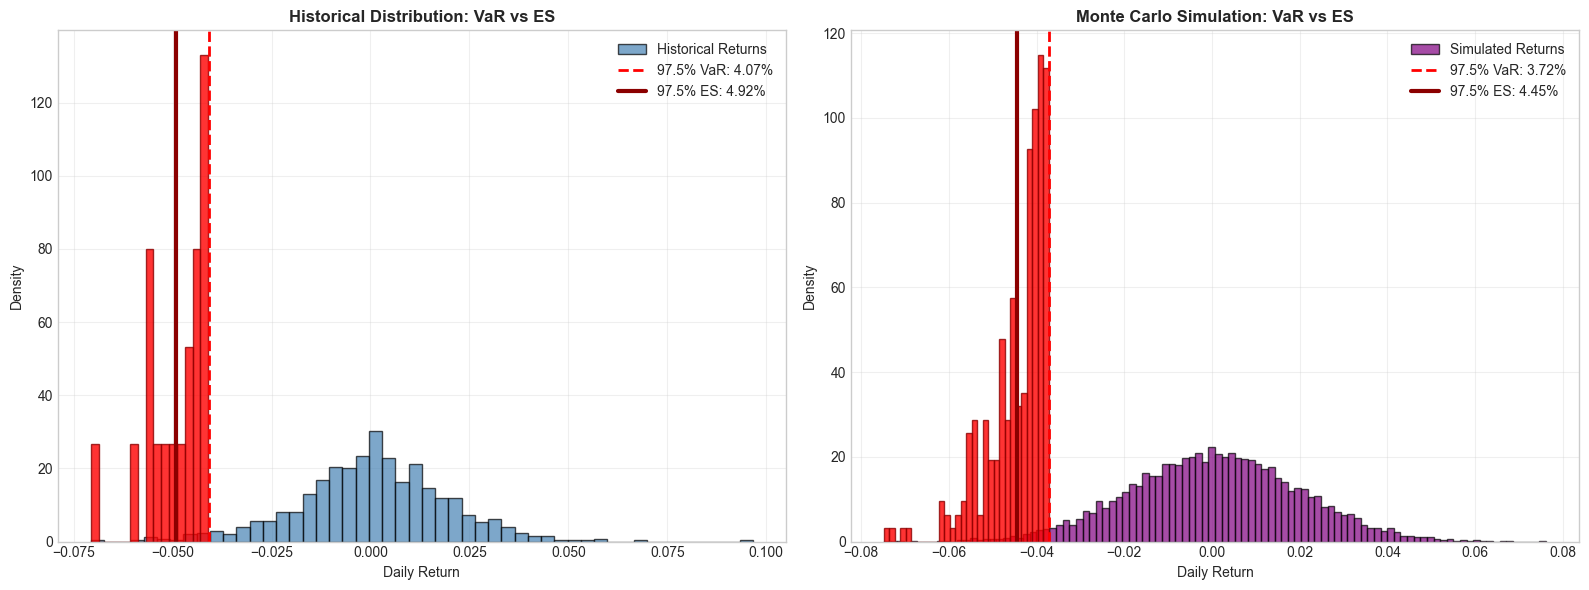

In [11]:
# Distribution with VaR and ES visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Historical returns
ax1 = axes[0]
ax1.hist(train_returns, bins=50, density=True, alpha=0.7, color='steelblue', 
         edgecolor='black', label='Historical Returns')

# VaR and ES lines (97.5%)
ax1.axvline(hist_var_975, color='red', linestyle='--', linewidth=2, 
            label=f'97.5% VaR: {abs(hist_var_975):.2%}')
ax1.axvline(hist_es_975, color='darkred', linestyle='-', linewidth=3, 
            label=f'97.5% ES: {abs(hist_es_975):.2%}')

# Shade tail area
tail_data = train_returns[train_returns <= hist_var_975]
ax1.hist(tail_data, bins=15, density=True, alpha=0.8, color='red', 
         edgecolor='darkred')

ax1.set_title('Historical Distribution: VaR vs ES', fontsize=12, fontweight='bold')
ax1.set_xlabel('Daily Return')
ax1.set_ylabel('Density')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: Monte Carlo simulation
ax2 = axes[1]
ax2.hist(simulated_returns, bins=100, density=True, alpha=0.7, color='purple', 
         edgecolor='black', label='Simulated Returns')

# VaR and ES lines
ax2.axvline(mc_var_975, color='red', linestyle='--', linewidth=2, 
            label=f'97.5% VaR: {abs(mc_var_975):.2%}')
ax2.axvline(mc_es_975, color='darkred', linestyle='-', linewidth=3, 
            label=f'97.5% ES: {abs(mc_es_975):.2%}')

# Shade tail
tail_sim = simulated_returns[simulated_returns <= mc_var_975]
ax2.hist(tail_sim, bins=30, density=True, alpha=0.8, color='red', 
         edgecolor='darkred')

ax2.set_title('Monte Carlo Simulation: VaR vs ES', fontsize=12, fontweight='bold')
ax2.set_xlabel('Daily Return')
ax2.set_ylabel('Density')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/03_var_vs_es.png', dpi=300, bbox_inches='tight')
plt.show()

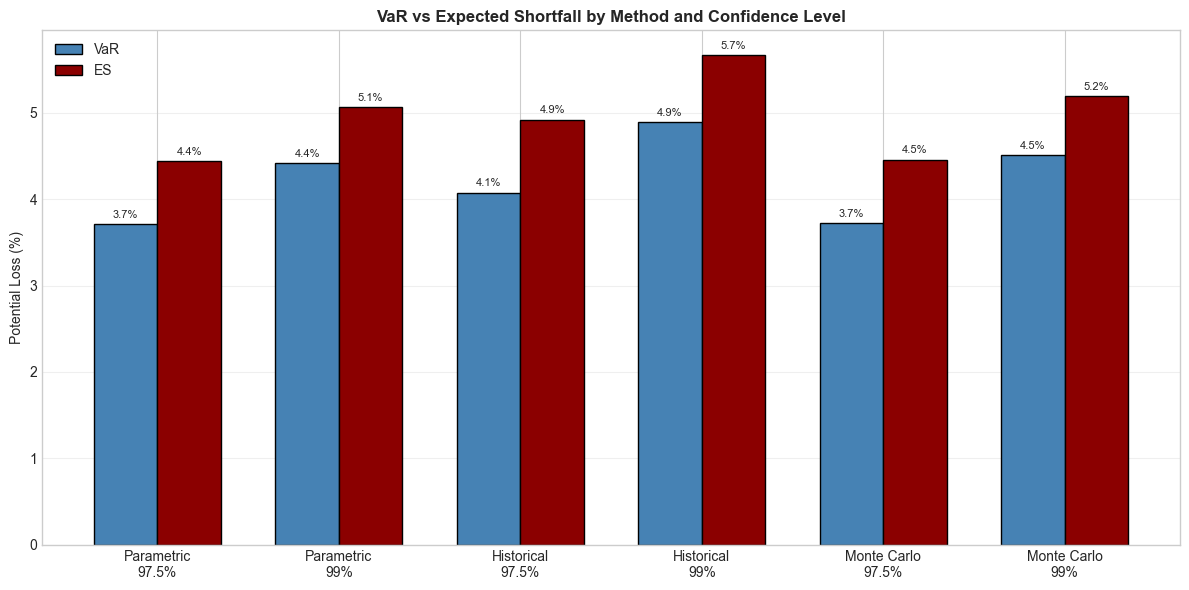

In [12]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))

methods = ['Parametric\n97.5%', 'Parametric\n99%', 'Historical\n97.5%', 
           'Historical\n99%', 'Monte Carlo\n97.5%', 'Monte Carlo\n99%']

var_values = [abs(param_var_975)*100, abs(param_var_99)*100, 
              abs(hist_var_975)*100, abs(hist_var_99)*100,
              abs(mc_var_975)*100, abs(mc_var_99)*100]

es_values = [abs(param_es_975)*100, abs(param_es_99)*100,
             abs(hist_es_975)*100, abs(hist_es_99)*100,
             abs(mc_es_975)*100, abs(mc_es_99)*100]

x = np.arange(len(methods))
width = 0.35

bars1 = ax.bar(x - width/2, var_values, width, label='VaR', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, es_values, width, label='ES', color='darkred', edgecolor='black')

ax.set_ylabel('Potential Loss (%)')
ax.set_title('VaR vs Expected Shortfall by Method and Confidence Level', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/figures/03_var_es_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 3.7 ES Premium Analysis

The "ES premium" represents how much additional risk is captured by ES compared to VaR.

In [13]:
# Calculate ES premium for different confidence levels
confidence_levels = [0.90, 0.95, 0.975, 0.99, 0.995]

es_analysis = []
for conf in confidence_levels:
    h_var = historical_var(train_returns, conf)
    h_es = historical_es(train_returns, conf)
    
    es_analysis.append({
        'Confidence': f"{conf*100:.1f}%",
        'VaR': abs(h_var),
        'ES': abs(h_es),
        'ES/VaR Ratio': abs(h_es) / abs(h_var),
        'Tail Observations': len(train_returns[train_returns <= h_var])
    })

es_analysis_df = pd.DataFrame(es_analysis)

display(Markdown("### ES Analysis Across Confidence Levels (Historical Method)"))
display(es_analysis_df.style.format({
    'VaR': '{:.2%}',
    'ES': '{:.2%}',
    'ES/VaR Ratio': '{:.2f}x'
}))

### ES Analysis Across Confidence Levels (Historical Method)

,Confidence,VaR,ES,ES/VaR Ratio,Tail Observations
0,90.0%,2.31%,3.47%,1.50x,74
1,95.0%,3.17%,4.26%,1.35x,37
2,97.5%,4.07%,4.92%,1.21x,19
3,99.0%,4.89%,5.67%,1.16x,8
4,99.5%,5.52%,6.07%,1.10x,4


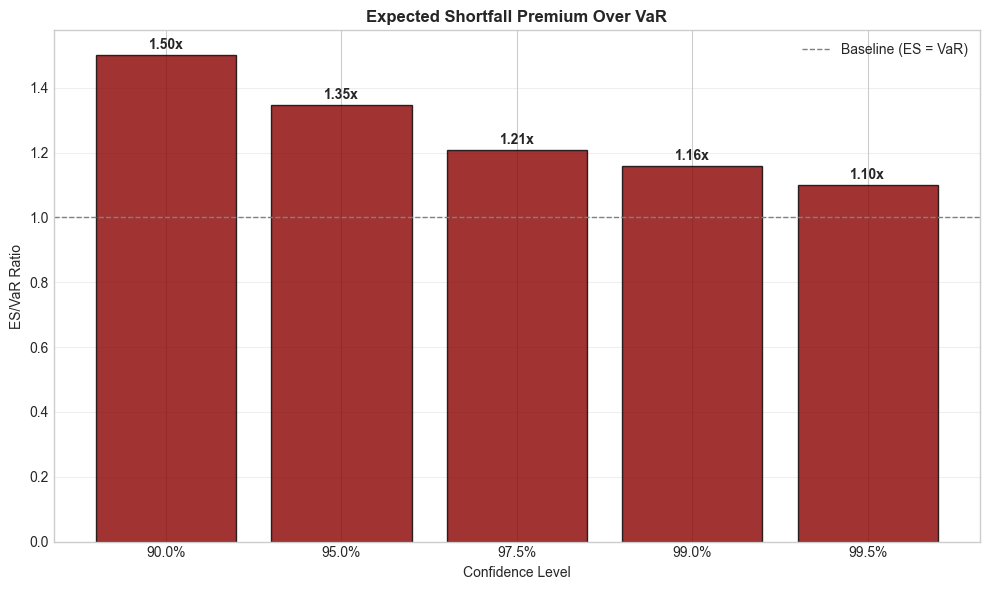

In [14]:
# Visualize ES/VaR ratio across confidence levels
fig, ax = plt.subplots(figsize=(10, 6))

conf_labels = [f"{c*100:.1f}%" for c in confidence_levels]
ratios = [row['ES/VaR Ratio'] for row in es_analysis]

bars = ax.bar(conf_labels, ratios, color='darkred', edgecolor='black', alpha=0.8)

ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, label='Baseline (ES = VaR)')

ax.set_xlabel('Confidence Level')
ax.set_ylabel('ES/VaR Ratio')
ax.set_title('Expected Shortfall Premium Over VaR', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{ratio:.2f}x', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/03_es_premium.png', dpi=300, bbox_inches='tight')
plt.show()

## 3.8 Save Results

In [15]:
# Save ES results
es_results = {
    'parametric': {
        'es_975': param_es_975,
        'es_99': param_es_99,
        'var_975': param_var_975,
        'var_99': param_var_99
    },
    'historical': {
        'es_975': hist_es_975,
        'es_99': hist_es_99,
        'var_975': hist_var_975,
        'var_99': hist_var_99
    },
    'monte_carlo': {
        'es_975': mc_es_975,
        'es_99': mc_es_99,
        'var_975': mc_var_975,
        'var_99': mc_var_99
    }
}

with open('../outputs/es_results.json', 'w') as f:
    json.dump(es_results, f, indent=4)

print("ES results saved to outputs/es_results.json")

ES results saved to outputs/es_results.json


---

## Summary

In this notebook, we implemented Expected Shortfall (ES/CVaR):

### Key Differences: VaR vs ES

| Feature | VaR | ES |
|---------|-----|----|
| Definition | Maximum loss at confidence level | Average loss beyond VaR |
| Tail Information | Ignores tail severity | Captures full tail |
| Subadditivity | Not subadditive | Subadditive (coherent) |
| Regulatory Use | Basel III | Basel IV / FRTB |
| Typical Ratio | Baseline | ~1.15-1.30x VaR |

### FRTB Requirement

The Fundamental Review of the Trading Book (FRTB) requires:
- **ES at 97.5% confidence** (replacing VaR at 99%)
- ES provides better incentive for diversification
- ES captures tail risk more completely

**Next Steps:**
In Notebook 04, we will implement Factor-Based VaR using a multi-factor model inspired by CAPM.